# 🟢 미션 1 (필수) — 내 문장의 빈칸을 모델이 채운다

수업 `## 6` 에서 한 것을 **내 문장 3개**로 한다.

## 낼 것

1. 세 문장의 **후보 5개 결과 캡처** (그래프 1장 포함)
2. 두 줄 — **잘 채운 것** 1개, **이상한 것** 1개 (아래 제출 칸)

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "missions" else Path.cwd()))

import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer

import koplot

koplot.use_korean()

tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
mlm = AutoModelForMaskedLM.from_pretrained("klue/bert-base")
mlm.eval()

[koplot] 한글 폰트 적용: Noto Sans KR


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: klue/bert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

## 1. 내 문장을 만든다

✍️ **아래 세 문장을 자기 문장으로 바꾼다.** 빈칸 자리에는 `{빈칸}` 을 그대로 둔다.

이런 것을 시험해 보면 재미있다 — 상식(수도·계절), 내 일상(취미·음식), 전공 용어.

In [2]:
빈칸 = tokenizer.mask_token

내문장들 = [
    f"겨울이 되면 {빈칸}이 내린다.",          # ✍️ 바꾼다
    f"제일 좋아하는 과목은 {빈칸}이다.",       # ✍️ 바꾼다
    f"퇴근하고 집에 가면 제일 먼저 {빈칸}을 한다.",  # ✍️ 바꾼다
]

## 2. 후보 5개를 확률과 함께 읽는다 — 수업 `## 6` 그대로

In [3]:
results = []

for sent in 내문장들:
    inputs = tokenizer(sent, return_tensors="pt")
    with torch.no_grad():
        outputs = mlm(**inputs)

    # [MASK] 자리 찾기 → 그 자리의 점수를 확률로 → 큰 값 5개 (수업 ## 6 그대로)
    mask_pos = (inputs["input_ids"][0] == tokenizer.mask_token_id).nonzero().item()
    probs = outputs.logits[0, mask_pos].softmax(dim=-1)    # 점수 → 확률 (합이 1)
    top = probs.topk(5)                                    # 큰 값 5개와 그 단어 번호

    cands = [(tokenizer.decode([idx]), p.item()) for p, idx in zip(top.values, top.indices)]
    results.append((sent, cands))

    print(sent)
    for word, p in cands:
        print(f"   {word:10s} {p:.3f}")
    print()

겨울이 되면 [MASK]이 내린다.
   눈          0.826
   첫눈         0.078
   폭설         0.032
   비          0.010
   함박         0.004

제일 좋아하는 과목은 [MASK]이다.
   수학         0.186
   영어         0.144
   국어         0.076
   경제학        0.038
   국사         0.035

퇴근하고 집에 가면 제일 먼저 [MASK]을 한다.
   출근         0.170
   퇴근         0.074
   스트레칭       0.030
   화장         0.026
   야근         0.022



## 3. 그래프 한 장 — 가장 마음에 드는 문장 하나를 고른다

findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.


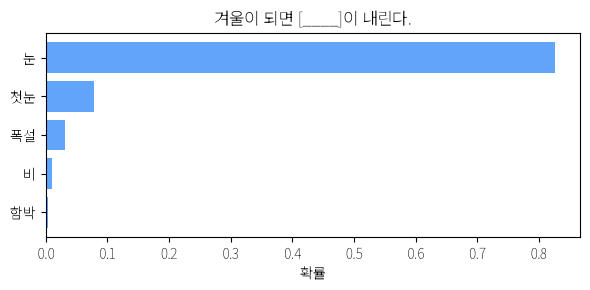

In [4]:
pick = 0                        # ✍️ 0, 1, 2 중에서 고른다

sent, cands = results[pick]
words = [w for w, _ in cands]
probs = [p for _, p in cands]

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(range(len(words))[::-1], probs, color="#60a5fa")
ax.set_yticks(range(len(words))[::-1], words)
ax.set_xlabel("확률")
ax.set_title(sent.replace(tokenizer.mask_token, "[____]"))
plt.tight_layout()
plt.show()

## ✍️ 제출 — 두 줄

> ① 잘 채운 것: "____ " 문장에서 모델이 ____ 를 골랐다.
> ② 이상한 것: "____ " 문장의 후보 ____ 는 어색했다. (왜 그런 것 같은가?)

> ⚠️ 확률 값은 문장이 다르면 완전히 달라진다. 옆 사람과 다른 게 정상이다.

## 더 해 보고 싶다면

같은 문장에서 **단어 하나만 바꿔** 보라 — "겨울이 되면" → "여름이 되면".
후보가 어떻게 바뀌는지 보는 것이 이 모델이 **문맥을 읽는다**는 가장 쉬운 증거다.